In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week2/wine.csv')

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [2]:
df2=df.drop('Wine',axis=1)
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
y=df2['Alcohol']
y.value_counts()
y

,Alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24
...,...
173,13.71
174,13.40
175,13.27
176,13.17


In [4]:
X=df2.drop('Alcohol',axis=1)
X.head()

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.4016852023007239
평균제곱오차 0.4016852023007239
평균제곱오차 0.40168520230072396


In [7]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=0)
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.6907666666666668
평균제곱오차 0.6907666666666668
평균제곱오차 0.6907666666666665


In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.4917587515555531
평균제곱오차 0.4917587515555531
평균제곱오차 0.4917587515555529


In [9]:
from sklearn.neighbors import KNeighborsRegressor

Wine_knn = KNeighborsRegressor(n_neighbors=5)
Wine_knn.fit(X_train, y_train)

pred_knn = Wine_knn.predict(X_test)

print ("\n--- KNeighborsRegressor ---")

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


--- KNeighborsRegressor ---
평균제곱오차 0.34925911111111185
평균제곱오차 0.34925911111111185
평균제곱오차 0.3492591111111118


In [10]:
# K값의 최적값을 찾기 위해 for문을 1~30까지 돌리고 그래프로 표현 Regression 에서는 MSE 값이 가장 작은값이 최적값


--- KNeighborsRegressor ---
최적의 k: 19
최소 평균제곱오차: 0.3247653370267778
평균제곱오차(sklearn) 0.3247653370267778
평균제곱오차(numpy) 0.3247653370267778
평균제곱오차(직접구현) 0.3247653370267778


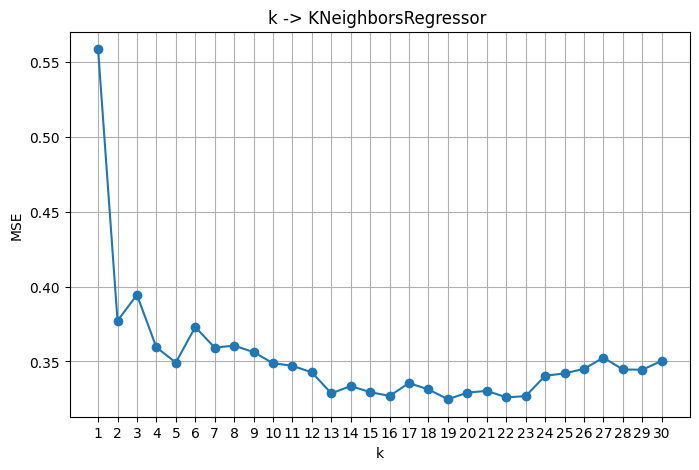

In [11]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

k_list = []
mse_list = []

#최적 k값 찾기
for k in range(1, 31):
    Wine_knn = KNeighborsRegressor(n_neighbors=k)
    Wine_knn.fit(X_train, y_train)

    pred_knn = Wine_knn.predict(X_test)

    error = mean_squared_error(y_test, pred_knn)

    k_list.append(k)
    mse_list.append(error)

best_k = k_list[np.argmin(mse_list)]
best_mse = min(mse_list)

print("\n--- KNeighborsRegressor ---")
print("최적의 k:", best_k)
print("최소 평균제곱오차:", best_mse)

# 최적 k로 다시 예측
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print('평균제곱오차(sklearn)', mean_squared_error(y_test, pred_knn))
print('평균제곱오차(numpy)', mse_np(y_test, pred_knn))
print('평균제곱오차(직접구현)', mse(y_test, pred_knn))

plt.figure(figsize=(8, 5))
plt.plot(k_list, mse_list, marker='o')
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("k -> KNeighborsRegressor ")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()